In [1]:
import numpy as np
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import time
from gwspace.constants import *
from scipy.special import jv
from sko.base import SkoBase
from sko.tools import func_transformer

In [2]:
def sinc(parameter):
    sinc = np.sin(parameter)/parameter
    return sinc

In [3]:
def fittingfactor(s1,s2,t):
    return np.trapz(s1*s2,x=t)/np.sqrt(np.trapz(s1*s1,x=t)*np.trapz(s2*s2,x=t))

In [4]:
M_BH = 4e6*MSUN_SI # 银河系中心黑洞质量
S_spin = 0.9 # 银河系中心黑洞自旋
Lamda_bh = 4.6583
Beta_bh = -0.0977
d = 8*KPC_SI # 银河系中心黑洞到地球的距离
e_ecc = 0.21 # XMRIs的轨道离心率
Rswc = 2*G_SI*M_BH/C_SI**2 # 黑洞的史瓦西半径：2GM/c^2
Rp = 4.33*Rswc # 近心点的距离
Ra = Rp/(1-e_ecc) # 半长轴的距离
f_orbit = np.sqrt(G_SI*M_BH/Ra**3)/(2*PI) # the orbit frequency
iota = np.pi/12
# initial phase
alpha0 = 1
gamma0 = 2
phi0 = 3
Beta_s = -0.3
lamda_s = 1.8

# TianQin轨道

In [5]:
TQArmLength_NU = 0.5777499579392                   # L/c 自然单位制, L = 16.6782
EarthEcc  = 0.0167                  #地球轨道的偏心率
EarthPeriod = 31516000          #地球周期，单位，秒
TQPeriod = 314496                #天琴周期,单位，秒
AU_NU = 499.0047837027308                  # 1AU ，太阳与地球之间的距离
Theta_J0806 = 1.652897
Phi_J0806 = 2.102137
Tobs = 86400*720
T_samp = 100
F_samp = 1/T_samp
t = np.arange(0, Tobs,T_samp)
Eta0 = 0
Delta0 = 0
Beta_s = -0.3
lamda_s = 1.8
def TQ_orbits(t,eta_0,delta_0,n):
    alpha_e = 2*np.pi/EarthPeriod*t+eta_0
    gamma_e = 2*np.pi/TQPeriod*t+2*np.pi*n/3+delta_0
    x_t = 0.5*AU_NU/TQArmLength_NU*EarthEcc*np.cos(2*alpha_e-3)+1/3**(1/2)*(np.cos(Theta_J0806)*np.cos(Phi_J0806)\
           *np.cos(gamma_e)-np.sin(Phi_J0806)*np.sin(gamma_e)) 
    y_t = 0.5*AU_NU/TQArmLength_NU*EarthEcc*np.sin(2*alpha_e)+1/3**(1/2)*(np.cos(Theta_J0806)*np.sin(Phi_J0806)\
           *np.cos(gamma_e)+np.cos(Phi_J0806)*np.sin(gamma_e)) 
    z_t = -1/3**(1/2)*(np.sin(Theta_J0806))*np.cos(gamma_e)
    TQ_orbits = np.array([x_t,y_t,z_t])
    return TQ_orbits
def vector_q(t,eta_0,delta_0):
    vector_q_1 = TQ_orbits(t,eta_0,delta_0,1)
    vector_q_2 = TQ_orbits(t,eta_0,delta_0,2)
    vector_q_3 = TQ_orbits(t,eta_0,delta_0,3)
    return np.array([vector_q_1,vector_q_2,vector_q_3])


def vector_k(beta,lamda):
    vectors_k_1 = -np.cos(lamda)*np.cos(beta)
    vectors_k_2 = -np.cos(beta)*np.sin(lamda)
    vectors_k_3 = -np.sin(beta)
    
    return np.array([vectors_k_1, vectors_k_2,vectors_k_3])

def vector_u(beta,lamda):
    vectors_u_1 = np.sin(beta)*np.cos(lamda)
    vectors_u_2 = np.sin(lamda)*np.sin(beta)
    vectors_u_3 = -np.cos(beta)
     
    return np.array([vectors_u_1,vectors_u_2,vectors_u_3])

def vector_v(lamda):
    vectors_v_1 = np.sin(lamda)              
    vectors_v_2 = -np.cos(lamda)
    vectors_v_3 = 0.0
   
    return np.array([vectors_v_1,vectors_v_2,vectors_v_3])

def vector_n(t,eta_0,delta_0):
    v_q = vector_q(t,eta_0,delta_0)
    vector_n_1 = v_q[1]-v_q[2]
    vector_n_2 = v_q[2]-v_q[0]
    vector_n_3 = v_q[0]-v_q[1]
    
    return np.array([vector_n_1,vector_n_2,vector_n_3])

def scalar_uv(vec_u, vec_v, vec_n):
    # 特别好用，爱因斯坦求和
    proj_u = np.einsum('j,ijl->il', vec_u, vec_n)
    proj_v = np.einsum('j,ijl->il', vec_v, vec_n)
    scalar_u = -0.5 * (proj_u**2 - proj_v**2)
    scalar_v = proj_u * proj_v
    return scalar_u, scalar_v


v_sqa = vector_q(t,Eta0,Delta0)
v_ka = vector_k(Beta_bh,Lamda_bh)
v_ua = vector_u(Beta_bh,Lamda_bh)
v_va = vector_v(Lamda_bh)
v_na = vector_n(t,Eta0,Delta0)
scalar_ua,scalar_va = scalar_uv(v_ua,v_va,v_na)

# 相位和内禀模板

In [6]:
def phase(n,f,f_dot,beta,lamda,eta_0,t):
    phi_t = n*(2*np.pi*f*t+0.5*2*np.pi*f_dot*t**2+
               (2*np.pi*f + 2*np.pi*f_dot*t)*AU_NU*np.cos(beta)*np.cos(2*np.pi/EarthPeriod*t+eta_0-lamda))
    return phi_t

In [7]:
def AET_intrinsic_waveform(scalar_u,scalar_v,f_GW,phit,t):
    Amp = 4*(2*np.pi*f_GW*TQArmLength_NU)**2
    A1 = 1/np.sqrt(2)*Amp*(scalar_u[0]-2*scalar_u[1]+scalar_u[2])*np.cos(phit)
    A2 = 1/np.sqrt(2)*Amp*(scalar_v[0]-2*scalar_v[1]+scalar_v[2])*np.cos(phit)
    A3 = 1/np.sqrt(2)*Amp*(scalar_u[0]-2*scalar_u[1]+scalar_u[2])*np.sin(phit)
    A4 = 1/np.sqrt(2)*Amp*(scalar_v[0]-2*scalar_v[1]+scalar_v[2])*np.sin(phit)
    
    E1 = np.sqrt(3/2)*Amp*(scalar_u[0]-scalar_u[2])*np.cos(phit)
    E2 = np.sqrt(3/2)*Amp*(scalar_v[0]-scalar_v[2])*np.cos(phit)
    E3 = np.sqrt(3/2)*Amp*(scalar_u[0]-scalar_u[2])*np.sin(phit)
    E4 = np.sqrt(3/2)*Amp*(scalar_v[0]-scalar_v[2])*np.sin(phit)
    
    T1 = np.zeros(len(scalar_u[0]))
    T2 = T1
    T3 = T1
    T4 = T1
    
    A = np.array([A1,A2,A3,A4])
    E = np.array([E1,E2,E3,E4])
    T = np.array([T1,T2,T3,T4])
    return A,E,T

# 外禀系数

In [8]:
def calculate_vec_L(f_orbit,ecc,Qx,s_spin,m_bh,iota,alpha0,t):
    alpha_dot = (4*PI*f_orbit*s_spin*(2*PI*G_SI*m_bh/C_SI**3*f_orbit)*(1-ecc**2)**(-1.5)
                +3*np.pi*f_orbit*Qx*(2*PI*G_SI*m_bh/C_SI**3*f_orbit)**(4/3)*(1-ecc**2)**(-2)*np.cos(iota))
    alpha = alpha0 + alpha_dot*t
    return np.array((-np.sin(alpha)*np.sin(iota),np.cos(alpha)*np.sin(iota),np.cos(iota)*np.ones(len(alpha))))
def from_ecliptic_to_Cartesian_coordinate(lamda,beta):
    '''
    这个函数的功能是将黄道坐标系的坐标变换为笛卡尔坐标。
    其中，向量的模为1.
    
    ***注意：这里需要注意theta和beta的定义的不同,theta是从北极点（Z轴的正方向）
    指到南极点（Z轴的负方向），范围为（0，pi);而beta是从赤道面出发，指向南北极，
    范围为（-pi/2,pi/2)。
    ***
    '''
    return np.array((np.cos(beta)*np.cos(lamda),np.cos(beta)*np.sin(lamda),np.sin(beta)))
def from_black_hole_to_ecliptic_coordinate(lamda_bh,beta_bh,lamda_s,beta_s,vec_x):
    '''
    这个函数的输入为黑洞的空间方位（lamda_bh,beta_bh)，黑洞自旋的方向（lamda_s,beta_s)，
    以及一个待转换坐标的向量vec_x。将vec_x的坐标从黑洞坐标系转换到黄道坐标系。其中，黑洞
    坐标系的Z轴为黑洞自旋的方向（这里假设不变），X轴为黑洞视线的方向在黑洞自旋赤道平面的投影。
    ******
    这里是一个旋转变换矩阵，从黄道变到黑洞更容易想，求出后直接取逆即为所需变换矩阵。
    R_Z(lamda_s)->R_Y(pi/2-beta_s)->R_Z(angle),此处的angle为经过前两步变换后，新的X轴，与黑洞
    坐标系X轴的夹角，这里需要注意正负的问题。综上，旋转矩阵为R_Z(angle)R_Y(pi/2-beta_s)R_Z(lamda_s)，
    其逆矩阵为(R_Z(angle)R_Y(pi/2-beta_s)R_Z(lamda_s))^(-1),即R_Z(-lamda_s)R_Y(-pi/2+beta_s)R_Z(-angle)。
    
    '''
    # 先计算一些基本的向量
    vec_n = from_ecliptic_to_Cartesian_coordinate(lamda_bh,beta_bh)
    vec_k = -vec_n
    vec_s_z = from_ecliptic_to_Cartesian_coordinate(lamda_s,beta_s)
    '''
    if ((lamda_bh == lamda_s and beta_bh==beta_s) or (lamda_bh == lamda_s+np.pi and beta_bh==-beta_s) or 
        (lamda_bh == lamda_s-np.pi and beta_bh==-beta_s)):
        vec_s_x_ryz_lamda=0
    '''
    '''
    if np.array_equal(vec_k,vec_s_z) or np.array_equal(vec_k,-vec_s_z):
        vec_s_x_ryz_lamda=0
   
    '''    
    cos_angle_k_s = np.dot(vec_k, vec_s_z)
    if np.isclose(abs(cos_angle_k_s), 1.0, rtol=0, atol=1e-10):
        vec_s_x_ryz_lamda=0
    else:
        vec_s_y = np.cross(vec_s_z,vec_k)/np.linalg.norm(np.cross(vec_s_z,vec_k))
        vec_s_x = np.cross(vec_s_y,vec_s_z)
        # 再去计算夹角angle
        # 计算vec_s_z在经过R_Y(pi/2-beta_s)R_Z(lamda_s)旋转后坐标系的坐标,右手坐标系，逆时针为正。
        def rotation_y_z(angle_y,angle_z):
            return np.array([[np.cos(angle_z)*np.cos(angle_y),np.sin(angle_z)*np.cos(angle_y),-np.sin(angle_y)],
                        [-np.sin(angle_z),np.cos(angle_z),0],
                         [np.sin(angle_y)*np.cos(angle_z),np.sin(angle_z)*np.sin(angle_y),np.cos(angle_y)]])
        Rot_Y_Z = rotation_y_z(np.pi/2-beta_s,lamda_s)
        vec_s_x_ryz = np.dot(Rot_Y_Z,vec_s_x)
        # 现在已经得到了黑洞坐标系X轴在中间阶段的旋转坐标系的坐标，因此可以求夹角了。
        def from_Cartesian_to_spherical_coordinate(vec_c):
            vec_beta = np.arcsin(vec_c[2])
            vec_lamda_sin = (vec_c[1]/np.cos(vec_beta))
            vec_lamda_cos = (vec_c[0]/np.cos(vec_beta))
            vec_lamda = np.arctan2(vec_lamda_sin, vec_lamda_cos)
            # 调整到 [0, 2pi)
            if vec_lamda < 0:
                vec_lamda += 2 * np.pi  
    
            return(vec_beta,vec_lamda)
        vec_s_x_ryz_beta,vec_s_x_ryz_lamda = from_Cartesian_to_spherical_coordinate(vec_s_x_ryz)    # vec_s_x_ryz_lamda即为所求角angle
    # 定义从黑洞坐标系到黄道坐标系的转动矩阵
    
    def rotationz2_y_z1(angle_y,angle_z1,angle_z2):
        return np.array([[-np.sin(angle_z1)*np.sin(angle_z2)+np.cos(angle_z1)*np.cos(angle_z2)*np.cos(angle_y),
                            np.cos(angle_z1)*np.sin(angle_z2)+np.sin(angle_z1)*np.cos(angle_z2)*np.cos(angle_y),
                            -np.sin(angle_y)*np.cos(angle_z2)],
                          [-np.sin(angle_z1)*np.cos(angle_z2)-np.cos(angle_z1)*np.sin(angle_z2)*np.cos(angle_y),
                            np.cos(angle_z1)*np.cos(angle_z2)-np.sin(angle_z1)*np.sin(angle_z2)*np.cos(angle_y),
                            np.sin(angle_y)*np.sin(angle_z2)],
                          [np.sin(angle_y)*np.cos(angle_z1),np.sin(angle_y)*np.sin(angle_z1),np.cos(angle_y)]])
    Rot_Z_Y_Z = rotationz2_y_z1(-np.pi/2+beta_s,-vec_s_x_ryz_lamda,-lamda_s)
    
    return np.dot(Rot_Z_Y_Z,vec_x)
def calculate_polarization_angle(lamda_bh,beta_bh,vec_L_ecliptic):
    
    vec_k = from_ecliptic_to_Cartesian_coordinate(lamda_bh,beta_bh)
    vec_u = np.array((np.sin(lamda_bh),-np.cos(lamda_bh),0))
    vec_v = np.array((-np.sin(beta_bh)*np.cos(lamda_bh),-np.sin(lamda_bh)*np.sin(beta_bh),np.cos(beta_bh)))
    vec_q = np.cross(vec_L_ecliptic.T,vec_k)#/np.linalg.norm((vec_L_ecliptic.T,vec_k))
    sin_psi = -np.dot(vec_q,vec_u)
    cos_psi =  np.dot(vec_q,vec_v)
    psi = np.arctan2(sin_psi,cos_psi)
    
    return psi
def beseel(e,n,ra):
    
    # Compute the semi-minor axis
    rb = ra*np.sqrt(1-e**2) 
    
    # Compute theindividual bessel functions of the first kind
    jm2 = jv(n-2,e*n)
    jp2 = jv(n+2,e*n)
    jm1 = jv(n-1,e*n)
    jp1 = jv(n+1,e*n)
    
    # Compute the coefficients
    An = ra**2/n*(jm2-jp2-2*e*jm1+2*e*jp1)
    Bn = rb**2/n*(jp2-jm2)
    Cn = ra*rb/n*(jm2+jp2-e*jm1-e*jp1)
    
    # Return the coefficints
    return An,Bn,Cn
def get_waveform_func(p_dict,n_harmonic):
    n1 = n_harmonic
    n2 = n_harmonic
    lamda_sx = p_dict['lamda_s'] # 如果这也在字典里
    beta_sx  = p_dict['beta_s']
    fx       = p_dict['f_orbit']     # 频率
    ex       = p_dict['e_ecc']     # 偏心率
    Sx       = p_dict['spin']        # 自旋，如果你固定为0.9
    Qx       = p_dict['Q']
    Mx       = p_dict['M_BH']      # 主黑洞质量
    mx       = p_dict['m_BD']     # 次天体质量（0.01-0.10）
    iotax    = p_dict['iota']  # 倾角
    alpha0x  = p_dict['alpha0']
    gamma0x  = p_dict['gmma0']
    phi0x    = p_dict['Phi0']
    
    # 先计算源坐标系下的theta，phi，psi
    mx = mx*MSUN_SI
    Mx = Mx*MSUN_SI
    mux = mx*Mx/(mx+Mx) # reduced mass
    mcx = (Mx*mx)**(3/5)/(Mx+mx)**(1/5) # chirp mass
    
    # The evolution of parameters: alpha, gamma, f
    f_dot = (48/5/PI*(G_SI*mcx/C_SI**3)**(5/3)*(2*PI*fx)**(11/3)*(1-ex**2)**(-9/2)*((1+73/24*ex**2+37/96*ex**4)*(1-ex**2)
            +(2*PI*G_SI*Mx/C_SI**3*fx)**(2/3)*(1273/336-2561/224*ex**2-3885/128*ex**4-13147/5376*ex**6)
            -(2*PI*G_SI*Mx/C_SI**3*fx)*Sx*np.cos(iotax)*(1-ex**2)**(-1/2)*(73/12+1211/24*ex**2+3143/96*ex**4+65/64*ex**6)
            -(2*PI*G_SI*Mx/C_SI**3*fx)**(4/3)*Qx*(1-ex**2)**(-1)*(33/16+359/32*ex**2-527/96*(np.sin(iotax))**2)))
    e_dot = (-ex/15*(G_SI*mcx/C_SI**3)**(5/3)*(2*np.pi*fx)**(8/3)*(1-ex**2)**(-7/2)*
             ((304+121*ex**2)*(1-ex**2)*(1+12*(2*PI*G_SI*Mx/C_SI**3*fx)**(2/3))
             -1/56*(2*PI*G_SI*Mx/C_SI**3*fx)**(2/3)*(8*16705+12*9082*ex**2-25211*ex**4))
             +ex*(G_SI*mcx/C_SI**3)**(5/3)*Sx*np.cos(iotax)*(2*np.pi*fx)**(11/3)*(1-ex**2)**(-4)*(1364/5+5032/15*ex**2+263/10*ex**4))
    alpha_dot = (4*PI*fx*Sx*(2*PI*G_SI*Mx/C_SI**3*fx)*(1-ex**2)**(-1.5)
                +3*np.pi*fx*Qx*(2*PI*G_SI*Mx/C_SI**3*fx)**(4/3)*(1-ex**2)**(-2)*np.cos(iotax))
    gamma_dot = (6*PI*fx*(2*PI*G_SI*Mx/C_SI**3*fx)**(2/3)*(1-ex**2)**(-1)*(1+0.25*(2*PI*G_SI*Mx/C_SI**3*fx)**(2/3)
                 *(26-15*ex**2)/(1-ex**2))-12*PI*fx*Sx*np.cos(iotax)*(2*PI*G_SI*Mx/C_SI**3*fx)*(1-ex**2)**(-3/2)
                 -3/2*np.pi*fx*Qx*(2*PI*G_SI*Mx/C_SI**3*fx)**(4/3)*(1-ex**2)**(-2)*(5*np.cos(iotax)-1))
    
    # Linear evolution
    alpha = alpha0x+alpha_dot*t
    gamma = gamma0x+gamma_dot*t
    e = ex+e_dot*t
    f = fx
    Rax = (G_SI*Mx)**(1/3)/(2*PI*f)**(2/3)
    vec_n = from_ecliptic_to_Cartesian_coordinate(Lamda_bh,Beta_bh)
    vec_k = -vec_n
    vec_s_z = from_ecliptic_to_Cartesian_coordinate(lamda_sx,beta_sx)
    deltax = np.arccos(np.dot(vec_k,vec_s_z))
    
    result_s = np.zeros_like(alpha, dtype=np.float64)
    result_c = np.ones_like(alpha, dtype=np.float64)
    costheta = np.sin(alpha)*np.sin(deltax)*np.sin(iotax)+np.cos(deltax)*np.cos(iotax)
    
    array_a = ((-np.sin(gamma)*np.sin(alpha)*np.cos(iotax)+np.cos(alpha)*np.cos(gamma))*np.sin(deltax)+np.sin(iotax)*np.cos(deltax)*np.sin(gamma))
    array_b = np.sqrt(1-costheta**2)
    array_c = (-(np.sin(gamma)*np.cos(alpha)+np.sin(alpha)*np.cos(gamma)*np.cos(iotax))*np.sin(deltax)+np.sin(iotax)*np.cos(gamma)*np.cos(deltax))
    
    sinphi = np.divide(array_a, array_b, out=result_s, where=(array_b != 0))
    cosphi = np.divide(array_c, array_b, out=result_c, where=(array_b != 0))
    
    vec_L = calculate_vec_L(f,e,Qx,Sx,Mx,iotax,alpha0x,t)
    vec_L_ecliptic = from_black_hole_to_ecliptic_coordinate(Lamda_bh,Beta_bh,lamda_sx,beta_sx,vec_L)
    psi = calculate_polarization_angle(Lamda_bh,Beta_bh,vec_L_ecliptic)
    
    
    n = n1
    X_At = np.zeros(len(alpha))
    X_Et = np.zeros(len(alpha))
    while n<=n2:
        
        
        An,Bn,Cn = beseel(e,n,Rax)
        
        
        # phase
        nphi0 = n*phi0x
        hn0 = (-mux*(2*np.pi*fx*n)**2)*G_SI/d/C_SI**4
        PHI = phase(n,f,f_dot,Beta_bh,Lamda_bh,Eta0,t)
        
        
        A_pc = An*(cosphi**2-sinphi**2*costheta**2)+Bn*(sinphi**2-cosphi**2*costheta**2)
        A_ps = -Cn*2*sinphi*cosphi*(1+costheta**2)
        A_cc = (An-Bn)*2*sinphi*cosphi*costheta
        A_cs = 2*Cn*(cosphi**2-sinphi**2)*costheta
        
        A1 = A_pc*np.cos(2*psi)-A_cc*np.sin(2*psi)
        A2 = A_pc*np.sin(2*psi)+A_cc*np.cos(2*psi)
        A3 = A_ps*np.cos(2*psi)-A_cs*np.sin(2*psi)
        A4 = A_ps*np.sin(2*psi)+A_cs*np.cos(2*psi)
        
        A,E,T = AET_intrinsic_waveform(scalar_ua,scalar_va,n*fx,PHI,t)
        
        hc_A = hn0*np.cos(nphi0)*(A1*A[0]+A2*A[1]+A3*A[2]+A4*A[3])
        hs_A = hn0*np.sin(nphi0)*(A3*A[0]+A4*A[1]-A1*A[2]-A2*A[3])
        
        hc_E = hn0*np.cos(nphi0)*(A1*E[0]+A2*E[1]+A3*E[2]+A4*E[3])
        hs_E = hn0*np.sin(nphi0)*(A3*E[0]+A4*E[1]-A1*E[2]-A2*E[3])
        
        
        X_At = X_At+hc_A+hs_A
        X_Et = X_Et+hc_E+hs_E
        n = n+1
        
        
    return X_At,X_Et

In [9]:
def SnA(f,L_TQ):
    if f==0:
        return 0
    else:
        return 8*np.sin(2*np.pi*f*L_TQ)**2*((6+4*np.cos(2*np.pi*f*L_TQ)+2*np.cos(2*2*np.pi*f*L_TQ))*SaTQ(f) + (2+np.cos(2*np.pi*f*L_TQ))*SxTQ(f) )

def SnT(f,L_TQ):
    if f==0:
        return 0
    else:
        return 32*np.sin(2*np.pi*f*L_TQ)**2*np.sin(2*np.pi*f*L_TQ/2)**2*(4*np.sin(2*np.pi*f*L_TQ/2)**2*SaTQ(f)+SxTQ(f))
c=3e8   
L = 3**0.5*1e8 # 天琴的L（单位是m）
L_TQ=L/c
def SaTQ(f):
    return (1e-30) * (2*np.pi*f*3e8)**-2
def SxTQ(f):
    return (1e-24) * (2*np.pi*f/(3e8))**2

In [10]:
'''
params = {
    'f_orbit': 4.917112e-5,
    'e_ecc':   0.7,
    'spin':    0.9,
    'M_BH':    4e6,
    'm_BD':    0.05,
    'alpha0':  1,
    'gmma0':   2,
    'Phi0':    3
}
'''
params = {'lamda_s': 1.8,
    'beta_s':  -0.3,
    'f_orbit': 0.0002226156834320294,
    'e_ecc':   0.21,
    'spin':    0.9,
    'Q':       -0.81,
    'M_BH':    4e6,
    'm_BD':    0.05,
    'iota':    np.pi/12,
    'alpha0':  1,
    'gmma0':   2.5,
    'Phi0':    3
}
listsnr=[]
listsnr_square=[]
i=1
while i <=8:
    Signal_As,Signal_Es = get_waveform_func(params,i)
    snr = (2*np.trapz((Signal_As * Signal_As), x=t)/SnA(f_orbit*i,L_TQ))+(2*np.trapz((Signal_Es * Signal_Es), x=t)/SnA(f_orbit*i,L_TQ))
    print('SNR_square',i,':',snr,'SNR',i,':',np.sqrt(snr))
    listsnr.append(np.sqrt(snr))
    listsnr_square.append(snr)
    i+=1

SNR_square 1 : 389.26190658949463 SNR 1 : 19.729721401720163
SNR_square 2 : 208480.02444263737 SNR 2 : 456.59612837017943
SNR_square 3 : 238746.34021667298 SNR 3 : 488.6167621118549
SNR_square 4 : 104044.95844317239 SNR 4 : 322.5600075073976
SNR_square 5 : 29181.397570532223 SNR 5 : 170.82563499232842
SNR_square 6 : 6330.130420643514 SNR 6 : 79.56211674310528
SNR_square 7 : 1159.2797884323268 SNR 7 : 34.04819802034062
SNR_square 8 : 188.22175126084556 SNR 8 : 13.719393254107324


In [11]:
np.sum(listsnr_square)

588519.6145399411

In [12]:
def inner_product(dh1, dh2, t, N, f_orbit):
    """
    计算特定谐波 N 下的内积
    """
    # 1. 确定当前谐波N对应的引力波频率,f_orbit为轨道基频
    f_target = N * f_orbit 
    
    # 2. 查该频率下的噪声值 Sn(f_target)
    # 假设 SnA 处理好了标量/数组问题
    sn = SnA(f_target, L_TQ) 
    
        
    # 3. 频域/时域内积公式
    # 注意：如果是在时域做积分，除以的是该频率点的 PSD 值
    integral = np.trapz(dh1 * dh2, x=t)
    return (2 * integral / sn)

def compute_single_harmonic_fim(params, dp_rates, get_waveform_func, t, N, f_orbit):
    """
    计算【单个谐波 N】贡献的 Fisher 矩阵
    """
    keys = list(params.keys())
    n_params = len(keys)
    fim_n = np.zeros((n_params, n_params))
    
    derivatives_A = {}
    derivatives_E = {}
    
    # --- 1. 计算偏导数 (针对第 N 个谐波) ---
    for p in keys:
        p_plus = params.copy()
        p_minus = params.copy()
        dx = dp_rates[p]
        
        p_plus[p] += dx
        p_minus[p] -= dx
        
        def get_phys_params(p_dict):
            # 将归一化的 1.0 乘以 原始物理常数
            return {k: p_dict[k] * physical_constants[k] for k in keys}

        XA_plus, XE_plus = get_waveform_func(get_phys_params(p_plus), n_harmonic=N)
        XA_minus, XE_minus = get_waveform_func(get_phys_params(p_minus), n_harmonic=N)
        
        derivatives_A[p] = (XA_plus - XA_minus) / (2 * dx)
        derivatives_E[p] = (XE_plus - XE_minus) / (2 * dx)

    # --- 2. 填充矩阵 ---
    for i in range(n_params):
        for j in range(i, n_params):
            val_A = inner_product(derivatives_A[keys[i]], derivatives_A[keys[j]], t, N, f_orbit)
            val_E = inner_product(derivatives_E[keys[i]], derivatives_E[keys[j]], t, N, f_orbit)
            
            res = val_A + val_E
            fim_n[i, j] = res
            fim_n[j, i] = res # 对称
            
    return fim_n

def compute_total_fim(params, dp_rates, get_waveform_func, t, N_max, f_orbit):
    """
    计算总 FIM：将 N=1 到 N_max 的所有谐波矩阵相加
    """
    keys = list(params.keys())
    n_params = len(keys)
    fim_total = np.zeros((n_params, n_params))
    
    #print(f"开始计算 FIM，共考虑 {N_max} 个谐波...")
    
    for N in range(1, N_max + 1):
        # 计算当前谐波的 FIM
        fim_current = compute_single_harmonic_fim(params, dp_rates, get_waveform_func, t, N, f_orbit)
        
        # 累加到总矩阵中 (Fisher 信息是可加的)
        fim_total += fim_current
        # 可选：打印进度
        # print(f"  已完成谐波 N={n} 的计算")
        
    return fim_total, keys

In [13]:
def check_fim_stability(fim, keys, dp_rates):
    """
    校验 FIM 矩阵的质量和步长设置的合理性
    """
    print("\n--- FIM 结果校验 ---")
    
    # 1. 检查条件数 (Condition Number)
    # 如果大于 1e15，说明矩阵接近奇异，不可逆，存在参数简并
    cond_num = np.linalg.cond(fim)
    print(f"矩阵条件数: {cond_num:.2e}")
    if cond_num > 1e16:
        print("【严重警告】矩阵条件数过大，结果不可信！可能存在参数强简并。")
        return None

    # 2. 求逆矩阵（协方差矩阵）
    try:
        cov = np.linalg.inv(fim)
    except np.linalg.LinAlgError:
        print("【错误】矩阵无法求逆。")
        return None

    # 3. 步长 vs 误差 自洽性检查
    print("\n参数精度与步长对比 (推荐比率在 0.1 到 10 之间):")
    print(f"{'Parameter':<10} | {'Input dx':<12} | {'Output Sigma':<12} | {'Ratio (dx/Sigma)':<15} | {'评价'}")
    print("-" * 70)
    
    is_good = True
    for i, key in enumerate(keys):
        sigma = np.sqrt(abs(cov[i, i])) # 估计误差 (1-sigma)
        dx = dp_rates[key]              # 你设定的步长
        
        if sigma == 0:
            ratio = np.inf
        else:
            ratio = dx / sigma
            
        # 评价逻辑
        if 0.01 <= ratio <= 100:
            status = "OK"
        elif ratio > 100:
            status = "dx 太大 (建议减小)"
            is_good = False
        else:
            status = "dx 太小 (可能引入噪点)" 
            # 注：dx偏小通常比偏大好，只要没碰到机器精度
            
        print(f"{key:<10} | {dx:.2e}   | {sigma:.2e}   | {ratio:.2f}            | {status}")

    if is_good:
        print("\n【结论】步长设置基本合理。")
    else:
        print("\n【建议】请根据上述提示调整 dp_rates，让 dx 更接近 Sigma。")
        
    return cov

In [14]:
import numpy as np

class FIM_Diagnostic_Tool:
    def __init__(self, params, base_dp_rates):
        self.params = params
        self.base_dp_rates = base_dp_rates
        self.keys = list(params.keys())

    def calculate_snr(self, get_waveform_func, t, N_max, f_signal, SnA_func, L_TQ):
        """
        原理3检查：计算总信噪比 (SNR)
        SNR^2 = 4 * sum( |h(f)|^2 / Sn(f) )
        这里在时域计算: SNR^2 = InnerProduct(h, h)
        """
        print("\n[诊断 1/3] 正在检查信噪比 (SNR)...")
        total_snr_sq = 0.0
        
        # 你的波形可能包含多个谐波，分别计算能量并叠加
        for n in range(1, N_max + 1):
            # 获取无扰动的原始波形
            XA, XE = get_waveform_func(self.params, n_harmonic=n)
            
            # 确定噪声
            f_target = n * f_signal
            sn = SnA_func(f_target, L_TQ)
            if isinstance(sn, np.ndarray): sn = sn.item() if sn.size==1 else sn[0]
            
            # 计算该谐波的能量 (A通道 + E通道)
            rho_A2 = 2 * np.trapz(XA**2, x=t) / sn
            rho_E2 = 2 * np.trapz(XE**2, x=t) / sn
            
            total_snr_sq += (rho_A2 + rho_E2)
            
        total_snr = np.sqrt(total_snr_sq)
        print(f"  >>> 总信噪比 SNR = {total_snr:.2f}")
        
        if total_snr < 10:
            print("  [警告] SNR < 10。FIM 近似可能失效（LSA条件不满足），结果可能低估误差。")
        else:
            print("  [通过] SNR 足够高，FIM 线性近似有效。")
            
        return total_snr

    def check_stability(self, compute_total_fim_func, get_waveform_func, t, N_max, f_signal):
        """
        原理1检查：数值收敛性测试
        分别用 dx, 2*dx, 0.5*dx 计算 FIM，看对角线元素变化是否剧烈。
        """
        print("\n[诊断 2/3] 正在检查数值微分稳定性 (Convergence Test)...")
        
        # 1. 基准步长计算
        fim_base, _ = compute_total_fim_func(self.params, self.base_dp_rates, get_waveform_func, t, N_max, f_signal)
        diag_base = np.diag(fim_base)
        
        # 2. 步长放大 2 倍
        rates_large = {k: v * 2.0 for k, v in self.base_dp_rates.items()}
        fim_large, _ = compute_total_fim_func(self.params, rates_large, get_waveform_func, t, N_max, f_signal)
        diag_large = np.diag(fim_large)
        
        # 3. 步长缩小 0.5 倍
        rates_small = {k: v * 0.5 for k, v in self.base_dp_rates.items()}
        fim_small, _ = compute_total_fim_func(self.params, rates_small, get_waveform_func, t, N_max, f_signal)
        diag_small = np.diag(fim_small)
        
        print(f"{'Parameter':<10} | {'Base F_ii':<12} | {'Diff (2x)':<12} | {'Diff (0.5x)':<12} | {'结论'}")
        print("-" * 75)
        
        stable_count = 0
        for i, key in enumerate(self.keys):
            # 避免除以零
            val = diag_base[i]
            if val == 0:
                print(f"{key:<10} | 0.00e+00     | N/A          | N/A          | 无法评估")
                continue
                
            # 计算相对变化率
            diff_large = abs((diag_large[i] - val) / val)
            diff_small = abs((diag_small[i] - val) / val)
            
            # 判断标准：变化率小于 5% 认为是稳定的
            if diff_large < 0.05 and diff_small < 0.05:
                status = "稳定"
                stable_count += 1
            else:
                status = "不稳定(!)"
            
            print(f"{key:<10} | {val:.2e}     | {diff_large:.2%}        | {diff_small:.2%}        | {status}")
            
        if stable_count == len(self.keys):
            print("  [通过] 所有参数的微分计算在当前步长下是稳定的。")
        else:
            print("  [警告] 部分参数微分不稳定，建议针对不稳定参数微调步长。")

        return fim_base # 返回基准矩阵供下一步使用

    def check_correlations(self, fim):
        """
        原理2检查：条件数与相关性分析
        """
        print("\n[诊断 3/3] 正在检查矩阵性质与参数简并 (Degeneracy)...")
        
        # 1. 条件数
        cond_num = np.linalg.cond(fim)
        print(f"  >>> FIM 条件数: {cond_num:.2e}")
        if cond_num > 1e15:
            print("  [严重警告] 矩阵接近奇异！求逆结果将极其不可靠。")
            print("            可能是因为参数间存在强简并，或者步长选取极度不合理。")
        
        # 2. 计算协方差与相关矩阵
        try:
            cov = np.linalg.inv(fim)
        except np.linalg.LinAlgError:
            print("  [错误] 矩阵无法求逆。")
            return

        # 归一化得到相关系数矩阵 Correlation Matrix
        # R_ij = Cov_ij / sqrt(Cov_ii * Cov_jj)
        d = np.sqrt(np.diag(cov))
        outer_d = np.outer(d, d)
        corr_matrix = cov / outer_d
        
        # 找出高相关性的参数对
        print("\n  >>> 强相关参数对 (Correlation > 0.95):")
        found_strong_corr = False
        n = len(self.keys)
        for i in range(n):
            for j in range(i + 1, n):
                corr = corr_matrix[i, j]
                if abs(corr) > 0.95:
                    found_strong_corr = True
                    print(f"      {self.keys[i]} <--> {self.keys[j]} : {corr:.4f}")
        
        if not found_strong_corr:
            print("      无强相关参数，参数解耦良好。")
        else:
            print("      注意：强相关意味着这几个参数很难单独被测准。")

        # 输出最终误差
        print("\n--- 最终参数估计误差 (1-sigma) ---")
        for i, key in enumerate(self.keys):
            # 这里的 sigma 实际上是理论推导出的相对误差 (delta_theta / theta)
            rel_sigma = np.sqrt(abs(cov[i, i]))
    
            # 真正的绝对误差应该是：相对误差 * 参数原值
            abs_sigma = rel_sigma * abs(self.params[key])
    
            # 打印时：
            # ± 后面接绝对误差 (abs_sigma)
            # 括号里接相对误差 (rel_sigma)
            print(f"{key:<10}: {self.params[key]:.2e} ± {abs_sigma:.2e} (相对误差: {rel_sigma:.2%})")

In [15]:
physical_constants = {
    'lamda_s': 1.8,
    'beta_s':  -0.3,
    'f_orbit': 0.0002226156834320294,
    'e_ecc':   0.21,
    'spin':    0.9,
    'Q':       -0.81,
    'M_BH':    4e6,  # 真实的质量
    'm_BD':    0.05,
    'iota':    np.pi/12,
    'alpha0':  1.0,
    'gmma0':   2.0,
    'Phi0':    3.0
}

# 2. 现在的 params 字典全设为 1.0（作为归一化参数）
params = {k: 1.0 for k in physical_constants.keys()}
dp_rates = {
    'lamda_s': 1e-3,          # 角度（弧度）
    'beta_s':  1e-3,          # 角度（弧度）
    'f_orbit': 1e-8,          # 频率非常敏感，步长需极小
    'e_ecc':   1e-5,          # 偏心率
    'spin':    5e-7,          # 无量纲自旋
    'Q':       5e-6,
    'M_BH':    1e-7,  # 大质量采用相对步长
    'm_BD':    1e-3,  # 次天体质量采用相对步长
    'iota':    5e-4,          # 倾角
    'alpha0':  1e-3,          # 初始相位
    'gmma0':   1e-3,
    'Phi0':    1e-4
}
dp_rates = {
    'lamda_s': 1e-4,          # 角度（弧度）
    'beta_s':  1e-4,          # 角度（弧度）
    'f_orbit': 1e-8,          # 频率非常敏感，步长需极小
    'e_ecc':   1e-5,          # 偏心率
    'spin':    2e-7,          # 无量纲自旋
    'Q':       5e-6,
    'M_BH':    1e-7,  # 大质量采用相对步长
    'm_BD':    1e-3,  # 次天体质量采用相对步长
    'iota':    1e-5,          # 倾角
    'alpha0':  1e-4,          # 初始相位
    'gmma0':   1e-4,
    'Phi0':    1e-4
}
'''
params = {
    'f_orbit': 4.917112e-5,
    'e_ecc':   0.7,
    'spin':    0.9,
    'M_BH':    4e6,
    'm_BD':    0.05,
    'alpha0':  1,
    'gmma0':   2,
    'Phi0':    3
}
# 2. 定义微分步长
# 必须确保 dp_rates 的 key 与 params 的 key 一一对应
dp_rates = {
    'f_orbit': 1e-11,          # 频率非常敏感，步长需极小
    'e_ecc':   1e-7,          # 偏心率
    'spin':    1e-7,          # 无量纲自旋
    'M_BH':    1e-7,  # 大质量采用相对步长
    'm_BD':    1e-7,  # 次天体质量采用相对步长
    'alpha0':  1e-7,          # 初始相位
    'gmma0':   1e-7,
    'Phi0':    1e-7
}
'''
fim, keys = compute_total_fim(params, dp_rates, get_waveform_func, t, 8, f_orbit)

# 5. 求逆得到协方差
cov = np.linalg.inv(fim)
# 提取 Q 参数（假设 Q 是 m）的误差
check_fim_stability(fim, keys, dp_rates)


--- FIM 结果校验 ---
矩阵条件数: 6.27e+13

参数精度与步长对比 (推荐比率在 0.1 到 10 之间):
Parameter  | Input dx     | Output Sigma | Ratio (dx/Sigma) | 评价
----------------------------------------------------------------------
lamda_s    | 1.00e-04   | 6.46e-03   | 0.02            | OK
beta_s     | 1.00e-04   | 2.84e-02   | 0.00            | dx 太小 (可能引入噪点)
f_orbit    | 1.00e-08   | 5.57e-08   | 0.18            | OK
e_ecc      | 1.00e-05   | 1.19e-03   | 0.01            | dx 太小 (可能引入噪点)
spin       | 2.00e-07   | 8.18e-03   | 0.00            | dx 太小 (可能引入噪点)
Q          | 5.00e-06   | 4.44e-02   | 0.00            | dx 太小 (可能引入噪点)
M_BH       | 1.00e-07   | 1.10e-03   | 0.00            | dx 太小 (可能引入噪点)
m_BD       | 1.00e-03   | 2.58e-03   | 0.39            | OK
iota       | 1.00e-05   | 6.90e-03   | 0.00            | dx 太小 (可能引入噪点)
alpha0     | 1.00e-04   | 1.76e-03   | 0.06            | OK
gmma0      | 1.00e-04   | 1.48e-02   | 0.01            | dx 太小 (可能引入噪点)
Phi0       | 1.00e-04   | 9.33e-04   | 0.11           

array([[ 4.17351198e-05, -1.61834082e-04, -8.98075519e-16,
        -3.31950073e-08,  2.08163815e-07,  8.89069264e-07,
        -1.84285591e-07,  2.23109891e-06,  7.71976276e-06,
        -6.19796505e-11, -9.26115959e-05,  9.76635863e-12],
       [-1.61834082e-04,  8.04962984e-04, -4.67502422e-15,
        -2.45006125e-07,  3.35066037e-07, -6.11294949e-08,
        -1.59755364e-06,  1.74719587e-05,  5.98820802e-05,
        -1.48210033e-07,  3.92830643e-04,  4.45891467e-11],
       [-8.98076130e-16, -4.67501397e-15,  3.10677922e-15,
        -8.02048072e-16,  8.48462851e-15,  1.30355085e-15,
        -1.75456341e-14,  2.32031074e-15, -4.31795115e-15,
         3.37092363e-16,  1.00080439e-10, -4.50475639e-11],
       [-3.31949776e-08, -2.45006234e-07, -8.02050728e-16,
         1.41219787e-06, -1.14173002e-06, -6.07925879e-06,
        -3.04269634e-07, -8.87756849e-07, -1.97724785e-07,
        -3.53906407e-07, -1.29447127e-07,  1.20949834e-11],
       [ 2.08161573e-07,  3.35068172e-07,  8.4847089

开始稳定性诊断...


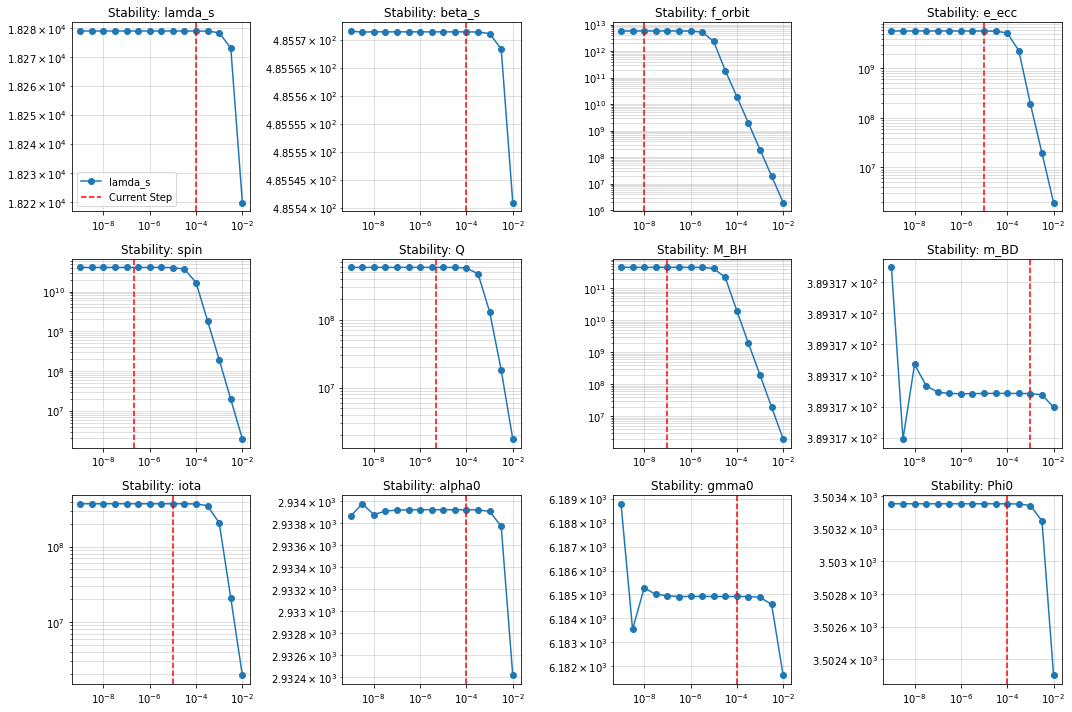

In [16]:
import matplotlib.pyplot as plt

def run_stability_diagnostic(params_norm, physical_constants, get_waveform_func, t, N_max):
    """
    检查每个参数的数值导数收敛性
    """
    # 扫描步长范围：从 1e-9 到 1e-2
    test_steps = np.logspace(-9, -2, 15)
    keys = list(params_norm.keys())
    f_phys = physical_constants['f_orbit']
    
    print("开始稳定性诊断...")
    plt.figure(figsize=(15, 10))
    
    for idx, p_key in enumerate(keys):
        fii_values = []
        for step in test_steps:
            # 构造临时的 dp_rates，只测试当前参数
            current_rates = {k: 1e-5 for k in keys} # 其他参数设为默认
            current_rates[p_key] = step
            
            # 计算单谐波或总 Fisher 的对角元（取第 1 个谐波测试即可，速度快）
            fim_n = compute_single_harmonic_fim(params_norm, current_rates, get_waveform_func, t, 1, f_phys)
            fii_values.append(fim_n[idx, idx])
            
        # 绘图：x轴是步长，y轴是 Fisher 对角元
        plt.subplot(3, 4, idx + 1)
        plt.loglog(test_steps, fii_values, 'o-', label=p_key)
        plt.axvline(dp_rates[p_key], color='r', linestyle='--', label='Current Step')
        plt.title(f"Stability: {p_key}")
        plt.grid(True, which="both", ls="-", alpha=0.5)
        if idx == 0: plt.legend()

    plt.tight_layout()
    plt.show()

# 调用方法：
run_stability_diagnostic(params, physical_constants, get_waveform_func, t, 8)

开始稳定性诊断...


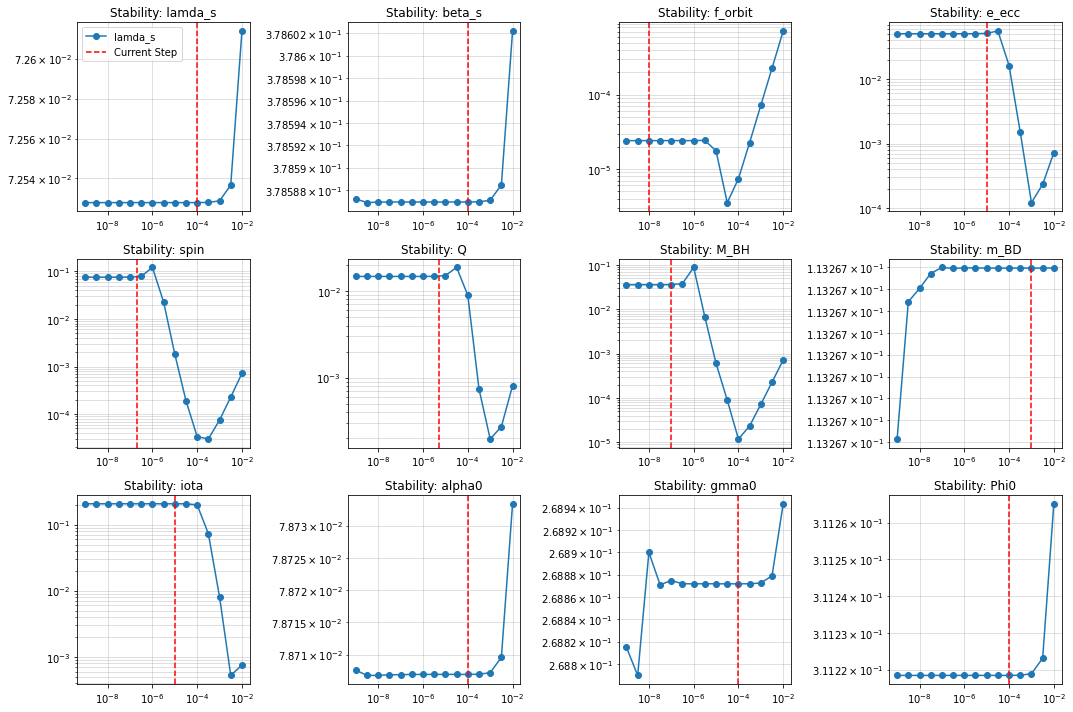

In [17]:
import matplotlib.pyplot as plt

def run_stability_diagnostic(params_norm, physical_constants, get_waveform_func, t, N_max):
    """
    检查每个参数的数值导数收敛性
    """
    # 扫描步长范围：从 1e-9 到 1e-2
    test_steps = np.logspace(-9, -2, 15)
    keys = list(params_norm.keys())
    f_phys = physical_constants['f_orbit']
    
    print("开始稳定性诊断...")
    plt.figure(figsize=(15, 10))
    
    for idx, p_key in enumerate(keys):
        list_sigma = []
        for step in test_steps:
            # 构造临时的 dp_rates，只测试当前参数
            current_rates = {k: 1e-5 for k in keys} # 其他参数设为默认
            current_rates[p_key] = step
            
            # 计算单谐波或总 Fisher 的对角元（取第 1 个谐波测试即可，速度快）
            fim_n = compute_single_harmonic_fim(params_norm, current_rates, get_waveform_func, t, 1, f_phys)
            cov = np.linalg.inv(fim_n)
            list_sigma.append(np.sqrt(abs(cov[idx, idx])))
            
        # 绘图：x轴是步长，y轴是 Fisher 对角元
        plt.subplot(3, 4, idx + 1)
        plt.loglog(test_steps, list_sigma, 'o-', label=p_key)
        plt.axvline(dp_rates[p_key], color='r', linestyle='--', label='Current Step')
        plt.title(f"Stability: {p_key}")
        plt.grid(True, which="both", ls="-", alpha=0.5)
        if idx == 0: plt.legend()

    plt.tight_layout()
    plt.show()

# 调用方法：
run_stability_diagnostic(params, physical_constants, get_waveform_func, t, 8)

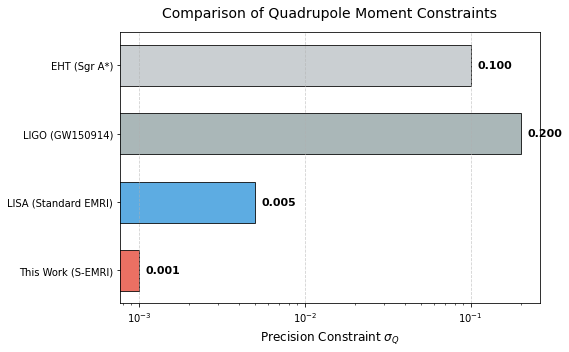

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 准备数据 ---
# 这里的数值为示例，请根据你查阅的文献进行修正
labels = ['EHT (Sgr A*)', 'LIGO (GW150914)', 'LISA (Standard EMRI)', 'This Work (S-EMRI)']
precisions = [0.1, 0.2, 0.005, 0.001]  # 对应 sigma_Q 的量级
colors = ['#bdc3c7', '#95a5a6', '#3498db', '#e74c3c'] # 灰色系对比红色

# --- 2. 开始绘图 ---
fig, ax = plt.subplots(figsize=(8, 5))

# 使用对数坐标，因为精度跨度很大
ax.set_xscale('log')

# 画横向条形图
bars = ax.barh(labels, precisions, color=colors, height=0.6, edgecolor='black', alpha=0.8)

# --- 3. 美化设置 ---
ax.set_xlabel(r'Precision Constraint $\sigma_Q$', fontsize=12)
ax.set_title('Comparison of Quadrupole Moment Constraints', fontsize=14, pad=15)
ax.invert_yaxis()  # 让你的结果排在最上面或最下面
ax.grid(axis='x', linestyle='--', alpha=0.6)

# 在条形图末端标注数值
for bar in bars:
    width = bar.get_width()
    ax.text(width * 1.1, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', va='center', fontsize=11, fontweight='bold')

# 添加一条物理红线：广义相对论预言值（假设为 0 误差位置）
# ax.axvline(x=1e-5, color='gray', linestyle=':', label='Theoretical Limit')

plt.tight_layout()
plt.show()

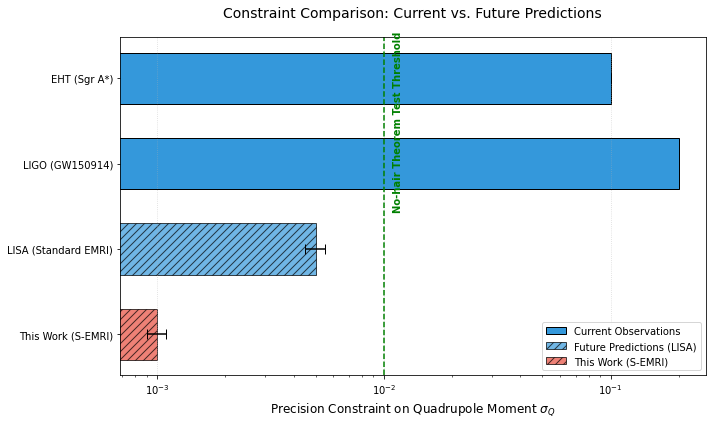

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 数据准备 ---
labels = ['EHT (Sgr A*)', 'LIGO (GW150914)', 'LISA (Standard EMRI)', 'This Work (S-EMRI)']
precisions = [0.1, 0.2, 0.005, 0.001]
# 假设通过步长扫描得到的数值涨落（误差棒）
errors = [0.0, 0.0, 0.0005, 0.0001] 

# 数据分类：哪些是已有的观测（Observed），哪些是预测（Predicted）
is_predicted = [False, False, True, True]

# --- 2. 绘图 ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xscale('log')

for i, (label, prec, err, pred) in enumerate(zip(labels, precisions, errors, is_predicted)):
    # 为预测数据添加斜纹（Hatch）
    hatch = '///' if pred else ''
    color = '#e74c3c' if label == 'This Work (S-EMRI)' else '#3498db'
    alpha = 0.7 if pred else 1.0
    
    # 画条形图
    ax.barh(label, prec, xerr=err, color=color, alpha=alpha, 
            hatch=hatch, edgecolor='black', capsize=5, height=0.6)

# --- 3. 添加物理门槛线 (Point B) ---
# 比如无毛定理验证通常需要的门槛 10^-2
ax.axvline(x=0.01, color='green', linestyle='--', linewidth=1.5)
ax.text(0.011, 0.5, 'No-hair Theorem Test Threshold', color='green', 
        rotation=90, va='center', fontsize=10, fontweight='bold')

# --- 4. 美化 ---
ax.set_xlabel(r'Precision Constraint on Quadrupole Moment $\sigma_Q$', fontsize=12)
ax.set_title('Constraint Comparison: Current vs. Future Predictions', fontsize=14, pad=20)
ax.invert_yaxis()
ax.grid(axis='x', linestyle=':', alpha=0.5)

# 添加图例说明
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label='Current Observations'),
    Patch(facecolor='#3498db', edgecolor='black', hatch='///', alpha=0.7, label='Future Predictions (LISA)'),
    Patch(facecolor='#e74c3c', edgecolor='black', hatch='///', alpha=0.7, label='This Work (S-EMRI)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

singular values (desc): [3.06796822e+16 3.21942550e+13 1.36381051e+13 2.30922639e+07
 6.74254718e+06 1.22900467e+06 4.70466795e+05 3.31541689e+05
 2.01368848e+05 1.37504659e+04]
pairs with |corr| > 0.9
beta_s gmma0 -0.9945259557285078
e_ecc M_BH -0.9862358471671672


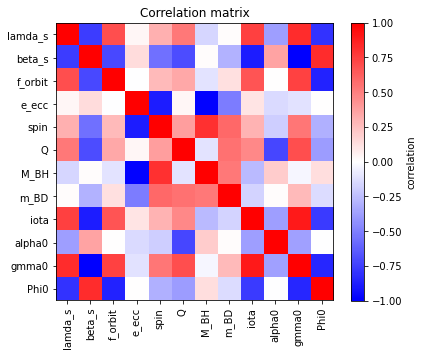

min eigvals (asc): [   489.13617904    961.34568499  13751.14314567 201369.07588076
 331541.68678752]
eig 0 val: 489.13617904239754
  spin    : 0.1808
  Q       : 0.9830
eig 1 val: 961.3456849944863
  lamda_s : 0.1827
  beta_s  : -0.8776
  iota    : -0.0518
  gmma0   : -0.4399
eig 2 val: 13751.14314566665
  lamda_s : 0.3037
  beta_s  : 0.2338
  m_BD    : 0.2317
  iota    : 0.7780
  gmma0   : -0.4398


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# load FIM
F = fim   # 或 np.loadtxt('F.txt')
names = ['lamda_s','beta_s','f_orbit','e_ecc','spin','Q','M_BH','m_BD','iota','alpha0','gmma0','Phi0']

# SVD 稳健求逆 -> covariance
u,s,vh = np.linalg.svd(F)
print("singular values (desc):", s[:10])
tol = s.max() * 1e-12
s_inv = np.array([1/si if si>tol else 0.0 for si in s])
cov = (vh.T * s_inv) @ u.T

sigma = np.sqrt(np.abs(np.diag(cov)))
corr = cov / np.outer(sigma, sigma)

# 打印相关对大于阈值的项
th = 0.9
n = len(names)
print("pairs with |corr| >", th)
for i in range(n):
    for j in range(i+1,n):
        if abs(corr[i,j])>th:
            print(names[i], names[j], corr[i,j])

# plot heatmap
plt.figure(figsize=(6,5))
plt.imshow(corr, vmin=-1, vmax=1, cmap='bwr', interpolation='nearest')
plt.colorbar(label='correlation')
plt.xticks(range(n), names, rotation=90)
plt.yticks(range(n), names)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

# eigen decomposition (F)
eigvals, eigvecs = np.linalg.eigh(F)  # 升序
print("min eigvals (asc):", eigvals[:5])
# 打印最小本征值对应的模式
k = 3
for i in range(k):
    idx = i
    print("eig", i, "val:", eigvals[idx])
    coeffs = eigvecs[:, idx]
    for nm,c in zip(names, coeffs):
        if abs(c) > 0.05:
            print(f"  {nm:8s}: {c:.4f}")


In [21]:
np.sqrt(cov[3,3])

0.0011796353714707082

In [22]:
check_fim_stability(fim, keys, dp_rates)


--- FIM 结果校验 ---
矩阵条件数: 6.27e+13

参数精度与步长对比 (推荐比率在 0.1 到 10 之间):
Parameter  | Input dx     | Output Sigma | Ratio (dx/Sigma) | 评价
----------------------------------------------------------------------
lamda_s    | 1.00e-04   | 6.46e-03   | 0.02            | OK
beta_s     | 1.00e-04   | 2.84e-02   | 0.00            | dx 太小 (可能引入噪点)
f_orbit    | 1.00e-08   | 5.57e-08   | 0.18            | OK
e_ecc      | 1.00e-05   | 1.19e-03   | 0.01            | dx 太小 (可能引入噪点)
spin       | 2.00e-07   | 8.18e-03   | 0.00            | dx 太小 (可能引入噪点)
Q          | 5.00e-06   | 4.44e-02   | 0.00            | dx 太小 (可能引入噪点)
M_BH       | 1.00e-07   | 1.10e-03   | 0.00            | dx 太小 (可能引入噪点)
m_BD       | 1.00e-03   | 2.58e-03   | 0.39            | OK
iota       | 1.00e-05   | 6.90e-03   | 0.00            | dx 太小 (可能引入噪点)
alpha0     | 1.00e-04   | 1.76e-03   | 0.06            | OK
gmma0      | 1.00e-04   | 1.48e-02   | 0.01            | dx 太小 (可能引入噪点)
Phi0       | 1.00e-04   | 9.33e-04   | 0.11           

array([[ 4.17351198e-05, -1.61834082e-04, -8.98075519e-16,
        -3.31950073e-08,  2.08163815e-07,  8.89069264e-07,
        -1.84285591e-07,  2.23109891e-06,  7.71976276e-06,
        -6.19796505e-11, -9.26115959e-05,  9.76635863e-12],
       [-1.61834082e-04,  8.04962984e-04, -4.67502422e-15,
        -2.45006125e-07,  3.35066037e-07, -6.11294949e-08,
        -1.59755364e-06,  1.74719587e-05,  5.98820802e-05,
        -1.48210033e-07,  3.92830643e-04,  4.45891467e-11],
       [-8.98076130e-16, -4.67501397e-15,  3.10677922e-15,
        -8.02048072e-16,  8.48462851e-15,  1.30355085e-15,
        -1.75456341e-14,  2.32031074e-15, -4.31795115e-15,
         3.37092363e-16,  1.00080439e-10, -4.50475639e-11],
       [-3.31949776e-08, -2.45006234e-07, -8.02050728e-16,
         1.41219787e-06, -1.14173002e-06, -6.07925879e-06,
        -3.04269634e-07, -8.87756849e-07, -1.97724785e-07,
        -3.53906407e-07, -1.29447127e-07,  1.20949834e-11],
       [ 2.08161573e-07,  3.35068172e-07,  8.4847089

In [23]:
import numpy as np
import matplotlib.pyplot as plt

class FIM_Diagnostic_Tool:
    def __init__(self, params_norm, base_dp_rates, physical_constants):
        """
        params_norm: 全为 1.0 的字典
        base_dp_rates: 相对步长字典 (如 1e-7)
        physical_constants: 真实的物理参数字典
        """
        self.params = params_norm
        self.base_dp_rates = base_dp_rates
        self.phys_constants = physical_constants
        self.keys = list(params_norm.keys())

    def _get_phys_dict(self, p_norm_dict):
        """内部辅助函数：将归一化的 1.0 字典还原为物理量字典"""
        return {k: p_norm_dict[k] * self.phys_constants[k] for k in self.keys}

    def calculate_snr(self, get_waveform_func, t, N_max, f_orbit_phys, SnA_func, L_TQ):
        """
        检查信号强度。注意：计算 SNR 必须使用物理量级的波形。
        """
        print("\n[诊断 1/3] 正在检查信噪比 (SNR)...")
        total_snr_sq = 0.0
        
        # 还原物理参数用于计算原始波形
        p_phys = self._get_phys_dict(self.params)
        
        for n in range(1, N_max + 1):
            # 直接调用你的原始波形函数
            XA, XE = get_waveform_func(p_phys, n_harmonic=n)
            
            f_target = n * f_orbit_phys
            sn = SnA_func(f_target, L_TQ)
            if isinstance(sn, np.ndarray): sn = sn[0]
            
            # 时域能量积分
            rho_A2 = 2 * np.trapz(XA**2, x=t) / sn
            rho_E2 = 2 * np.trapz(XE**2, x=t) / sn
            total_snr_sq += (rho_A2 + rho_E2)
            
        total_snr = np.sqrt(total_snr_sq)
        print(f"  >>> 总信噪比 SNR = {total_snr:.2f}")
        return total_snr

    def check_stability(self, compute_total_fim_func, get_waveform_func, t, N_max, f_orbit_phys):
        """
        检查数值微分的稳定性。
        通过改变步长 (0.5x, 1x, 2x)，观察 FIM 对角线元素 F_ii 的波动情况。
        """
        print("\n[诊断 2/3] 正在检查数值微分稳定性 (Convergence Test)...")
        
        # 1. 基准步长 (1x)
        fim_base, _ = compute_total_fim_func(self.params, self.base_dp_rates, get_waveform_func, t, N_max, f_orbit_phys)
        diag_base = np.diag(fim_base)
        
        # 2. 步长放大 (2x)
        rates_large = {k: v * 2.0 for k, v in self.base_dp_rates.items()}
        fim_large, _ = compute_total_fim_func(self.params, rates_large, get_waveform_func, t, N_max, f_orbit_phys)
        diag_large = np.diag(fim_large)
        
        # 3. 步长缩小 (0.5x)
        rates_small = {k: v * 0.5 for k, v in self.base_dp_rates.items()}
        fim_small, _ = compute_total_fim_func(self.params, rates_small, get_waveform_func, t, N_max, f_orbit_phys)
        diag_small = np.diag(fim_small)
        
        print(f"{'参数':<10} | {'基准 F_ii':<12} | {'2x步长偏差':<10} | {'0.5x步长偏差':<10} | {'结论'}")
        print("-" * 80)
        
        for i, key in enumerate(self.keys):
            val = diag_base[i]
            if val == 0: continue
            
            diff_l = abs((diag_large[i] - val) / val)
            diff_s = abs((diag_small[i] - val) / val)
            
            status = "稳定" if (diff_l < 0.05 and diff_s < 0.05) else "不稳定(!)"
            print(f"{key:<10} | {val:.2e} | {diff_l:.2%} | {diff_s:.2%} | {status}")
            
        return fim_base

    def check_correlations(self, fim):
        """
        检查矩阵病态程度，并输出最终的物理误差估计。
        """
        print("\n[诊断 3/3] 正在检查参数简并与最终误差...")
        cond_num = np.linalg.cond(fim)
        print(f"  >>> FIM 条件数: {cond_num:.2e}")
        
        try:
            prior_M = 1.0 / ( (0.01)**2 ) # 归一化后的相对误差先验
            prior_spin = 1.0 / ( (0.2)**2 )

            keys_list = list(params.keys())
            idx_M = keys_list.index('M_BH')
            idx_spin = keys_list.index('spin')

            # 在求逆前注入先验
            fim_with_prior = fim.copy()
            fim_with_prior[idx_M, idx_M] += prior_M
            fim_with_prior[idx_spin, idx_spin] += prior_spin
            cov = np.linalg.inv(fim)
        except np.linalg.LinAlgError:
            print("  [错误] 矩阵奇异，无法求逆。请检查步长或物理简并。")
            return

        # 计算相关系数矩阵
        d = np.sqrt(np.abs(np.diag(cov)))
        corr_matrix = cov / np.outer(d, d)
        
        print("\n--- 最终参数估计误差 (1-sigma) ---")
        for i, key in enumerate(self.keys):
            # rel_sigma 实际上是 Delta_theta / theta_0
            rel_sigma = np.sqrt(abs(cov[i, i]))
            
            # 还原物理误差：相对误差 * 物理真值
            phys_val = self.phys_constants[key]
            abs_sigma = rel_sigma * abs(phys_val)
            
            print(f"{key:<10}: 真值={phys_val:.2e} ± {abs_sigma:.2e} (相对误差: {rel_sigma:.2%})")

In [24]:
dp_rates = {
    'lamda_s': 1e-4,          # 角度（弧度）
    'beta_s':  1e-4,          # 角度（弧度）
    'f_orbit': 1e-8,          # 频率非常敏感，步长需极小
    'e_ecc':   1e-5,          # 偏心率
    'spin':    2e-7,          # 无量纲自旋
    'Q':       5e-6,
    'M_BH':    1e-7,  # 大质量采用相对步长
    'm_BD':    1e-3,  # 次天体质量采用相对步长
    'iota':    1e-5,          # 倾角
    'alpha0':  1e-4,          # 初始相位
    'gmma0':   1e-4,
    'Phi0':    1e-4
}

In [25]:
# 1. 准备数据（使用你定义的物理常数和归一化参数）
# physical_constants = {...}
# params = {k: 1.0 for k in physical_constants.keys()}
# dp_rates = {...}

# 2. 实例化诊断工具
diag_tool = FIM_Diagnostic_Tool(params, dp_rates, physical_constants)

# 3. 运行诊断
# 这里的 f_orbit 必须传物理真值，比如 2.22e-4
f_phys = physical_constants['f_orbit']

# 步骤 A: 检查 SNR
diag_tool.calculate_snr(get_waveform_func, t, 8, f_phys, SnA, L_TQ)

# 步骤 B: 检查稳定性（它会调用你的 compute_total_fim）
# 如果输出中 M_BH 对应的“偏差”很小，说明 1e-7 是安全的
fim_matrix = diag_tool.check_stability(compute_total_fim, get_waveform_func, t, 8, f_phys)

# 步骤 C: 检查简并并打印最终物理误差
diag_tool.check_correlations(fim_matrix)


[诊断 1/3] 正在检查信噪比 (SNR)...
  >>> 总信噪比 SNR = 767.15

[诊断 2/3] 正在检查数值微分稳定性 (Convergence Test)...
参数         | 基准 F_ii      | 2x步长偏差     | 0.5x步长偏差   | 结论
--------------------------------------------------------------------------------
lamda_s    | 2.76e+07 | 0.00% | 0.00% | 稳定
beta_s     | 7.34e+05 | 0.00% | 0.00% | 稳定
f_orbit    | 3.00e+16 | 0.00% | 0.00% | 稳定
e_ecc      | 8.69e+12 | 0.28% | 0.07% | 稳定
spin       | 6.19e+13 | 0.00% | 0.00% | 稳定
Q          | 8.93e+11 | 0.02% | 0.00% | 稳定
M_BH       | 6.93e+14 | 0.00% | 0.00% | 稳定
m_BD       | 5.89e+05 | 0.00% | 0.00% | 稳定
iota       | 5.68e+11 | 0.02% | 0.00% | 稳定
alpha0     | 4.46e+06 | 0.00% | 0.00% | 稳定
gmma0      | 9.42e+06 | 0.00% | 0.00% | 稳定
Phi0       | 5.11e+07 | 0.00% | 0.00% | 稳定

[诊断 3/3] 正在检查参数简并与最终误差...
  >>> FIM 条件数: 6.27e+13

--- 最终参数估计误差 (1-sigma) ---
lamda_s   : 真值=1.80e+00 ± 1.16e-02 (相对误差: 0.65%)
beta_s    : 真值=-3.00e-01 ± 8.51e-03 (相对误差: 2.84%)
f_orbit   : 真值=2.23e-04 ± 1.24e-11 (相对误差: 0.00%)
e_ecc     : 真值=2.10e-01 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 配置每个参数特有的扫描范围 (start_power, end_power, num_points)
# 如果某个参数没在字典里，我们将使用默认范围 (-12, -2)
param_ranges = {
    'f_orbit': (-20, -6, 200),  # 频率非常敏感，扫描更小的步长
    'M_BH':    (-12, -4, 200),   # 大质量
    'lamda_s': (-12, -2, 200),   # 角度
    'beta_s':  (-12, -2, 200),
    'e_ecc':   (-12, -2, 200),
    'spin':    (-12, -2, 200),
    'Q':       (-12, -2, 200),
    'm_BD':    (-12, -2, 200),
    'iota':    (-12, -2, 200),
    'alpha0':  (-12, -2, 200),
    'gmma0':   (-12, -2, 200),
    'Phi0':    (-12, -2, 200),
}

# 2. 设置 PRD 期刊绘图风格
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.top": True,
    "ytick.right": True
})

# 3. 创建输出目录
output_dir = "No-Hair-Theorem-Test-FIM_0203"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 4. 开始参数循环
for target_param in dp_rates.keys():
    print(f"正在分析参数: {target_param} ...")
    
    # 获取当前参数的步长扫描范围
    if target_param in param_ranges:
        start, end, num = param_ranges[target_param]
    else:
        start, end, num = -12, -2, 100 # 默认值
    
    steps = np.logspace(start, end, num)
    
    list_Fii = []
    list_sigma = []

    # 数值扫描计算
    for dx in steps:
        current_dp_rates = dp_rates.copy()
        current_dp_rates[target_param] = dx
        
        # 计算 FIM (此处 N_max 取 8)
        fim, keys = compute_total_fim(params, current_dp_rates, get_waveform_func, t, 8, params['f_orbit'])
        
        idx = keys.index(target_param)
        list_Fii.append(fim[idx, idx])
        
        try:
            cov = np.linalg.inv(fim)
            # 记录相对误差 (因为导数乘以了 theta，逆矩阵开方即为相对误差)
            list_sigma.append(np.sqrt(abs(cov[idx, idx])))
        except np.linalg.LinAlgError:
            list_sigma.append(np.nan)

    # --- 绘图逻辑 ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

    # 左图：FIM 元素 Γii
    ax1.loglog(steps, list_Fii, color='blue', lw=2, label=r'$\Gamma_{ii}$')
    ax1.set_xlabel(r'Relative Step Size $\Delta \theta_i / \theta_i$', fontsize=13)
    ax1.set_ylabel(r'FIM Element $\Gamma_{ii}$', fontsize=13)
    ax1.set_title(f'Convergence: {target_param}', fontsize=12)
    ax1.grid(alpha=0.3, linestyle='--')

    # 右图：误差估计 σi (相对精度)
    ax2.loglog(steps, list_sigma, color='darkorange', lw=2, label=r'$\sigma_i$')
    ax2.set_xlabel(r'Relative Step Size $\Delta \theta_i / \theta_i$', fontsize=13)
    ax2.set_ylabel(r'Relative Error $\Delta \theta_i / \theta_i$', fontsize=13)
    ax2.set_title('Matrix Stability', fontsize=12)
    ax2.grid(alpha=0.3, linestyle='--')

    plt.tight_layout()

    # 保存图片
    save_path = os.path.join(output_dir, f"XMRIs_0204_Convergence_{target_param}.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.close() # 关闭当前画布，节省内存

print(f"\n所有参数扫描完成！结果已保存至文件夹: {output_dir}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 设置绘图环境 (PRD 风格) ---
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

output_dir = "Q_Accuracy_Analysis_0204"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# --- 2. 定义扫描配置 ---
# 注意：确保此时的 dp_rates 是你之前调优过的“黄金步长”
scans = [
    {'name': 'iota', 'range': np.linspace(0.1, np.pi - 0.1, 50), 'xlabel': r'Inclination $\iota$ [rad]'},
    {'name': 'spin', 'range': np.linspace(0.01, 0.99, 50), 'xlabel': r'Dimensionless Spin $s$'},
    {'name': 'm_BD', 'range': np.linspace(0.01, 0.10, 50), 'xlabel': r'Secondary Mass $m_{BD} [M_\odot]$'}
]

# 找到 Q 在 FIM 矩阵中的索引位置
q_idx = list(dp_rates.keys()).index('Q')

for scan in scans:
    target_name = scan['name']
    target_range = scan['range']
    list_sigma_Q = []
    
    print(f"正在扫描 {target_name} 对 Q 精度的影响...")
    
    # 备份原始参数，以免污染后续循环
    original_params = params.copy()
    
    for val in target_range:
        current_params = original_params.copy()
        current_params[target_name] = val
        
        # 计算 FIM (此处 N_max 取 8)
        # 注意：此处使用的 dp_rates 应为你选定的稳定步长字典
        fim, keys = compute_total_fim(current_params, dp_rates, get_waveform_func, t, 8, current_params['f_orbit'])
        
        try:
            cov = np.linalg.inv(fim)
            # 因为是对数导数，sigma 直接对应相对误差 Delta_Q / Q
            sigma_q = np.sqrt(abs(cov[q_idx, q_idx]))
            list_sigma_Q.append(sigma_q)
        except np.linalg.LinAlgError:
            list_sigma_Q.append(np.nan)
            
    # --- 绘图 ---
    plt.figure(figsize=(6, 5))
    plt.plot(target_range, list_sigma_Q, color='blue', lw=2, marker='o', markersize=4, markerfacecolor='white')
    
    plt.yscale('log') # 误差通常跨越多个量级，对数轴更清晰
    plt.xlabel(scan['xlabel'], fontsize=13)
    plt.ylabel(r'Relative Error $\Delta Q / Q$', fontsize=13)
    plt.title(f'Sensitivity Analysis: $Q$ vs {target_name}', fontsize=12)
    plt.grid(alpha=0.3, linestyle='--')
    
    save_path = os.path.join(output_dir, f"SigmaQ_vs_{target_name}.png")
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

In [ ]:
params = {'lamda_s': 1.8,
    'beta_s':  -0.3,
    'f_orbit': 0.0002226156834320294,
    'e_ecc':   0.21,
    'spin':    0.9,
    'Q':       -0.81,
    'M_BH':    4e6,
    'm_BD':    0.05,
    'iota':    np.pi/12,
    'alpha0':  1,
    'gmma0':   2,
    'Phi0':    3
}
dp_rates = {
    'lamda_s': 1e-3,          # 角度（弧度）
    'beta_s':  1e-3,          # 角度（弧度）
    'f_orbit': 1e-13,          # 频率非常敏感，步长需极小
    'e_ecc':   1e-9,          # 偏心率
    'spin':    1e-8,          # 无量纲自旋
    'Q':       1e-6,
    'M_BH':    1e-7,  # 大质量采用相对步长
    'm_BD':    1e-4,  # 次天体质量采用相对步长
    'iota':    1e-6,          # 倾角
    'alpha0':  1e-3,          # 初始相位
    'gmma0':   1e-3,
    'Phi0':    1e-4
}
# 假设我们要研究参数 'm_BD' 的步长影响
target_param = 'spin'
steps = np.logspace(-12, -2, 10) # 生成 100 个对数间距的步长

list_Fii = []  # 存储 FIM 元素
list_sigma = [] # 存储最终误差 (sqrt(Cov_ii))

for dx in steps:
    # 构造当前步长的 dp_rates
    current_dp_rates = dp_rates.copy()
    current_dp_rates[target_param] = dx
    
    # 1. 计算 FIM
    fim, keys = compute_total_fim(params, current_dp_rates, get_waveform_func, t, 8, params['f_orbit'])
    
    # 2. 提取 FIM 对角线元素 (对应该参数的索引)
    idx = keys.index(target_param)
    list_Fii.append(fim[idx, idx])
    
    # 3. 计算逆矩阵并提取 sigma
    try:
        cov = np.linalg.inv(fim)
        list_sigma.append(np.sqrt(cov[idx, idx]))
    except np.linalg.LinAlgError:
        list_sigma.append(np.nan) # 如果矩阵奇异，记录为空

# --- 绘图分析 ---
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.loglog(steps, list_Fii, label='FIM element (F_ii)')
plt.xlabel('Step size (dx)')
plt.title(f'Information vs Step Size: {target_param}')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.loglog(steps, list_sigma, color='orange', label='Error (sigma_i)')
plt.xlabel('Step size (dx)')
plt.title(f'Estimated Error vs Step Size')
plt.grid(True)

plt.tight_layout()
plt.show()